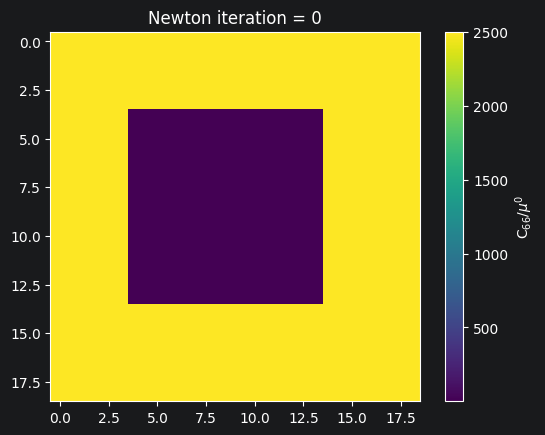

nb steps of CG = 222
  2.82e+00


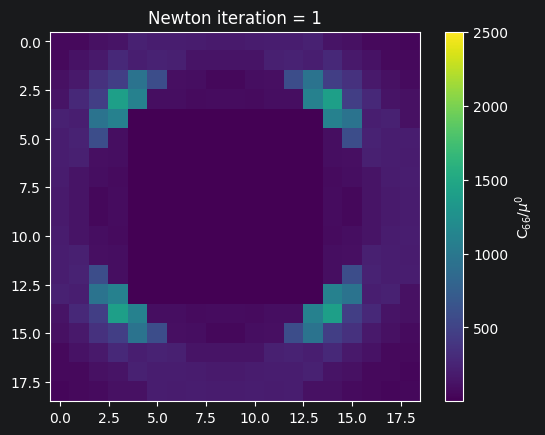

nb steps of CG = 383
  1.65e+00


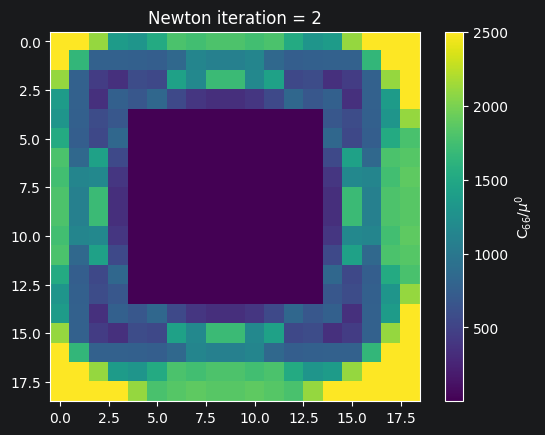

nb steps of CG = 258
  3.26e-01


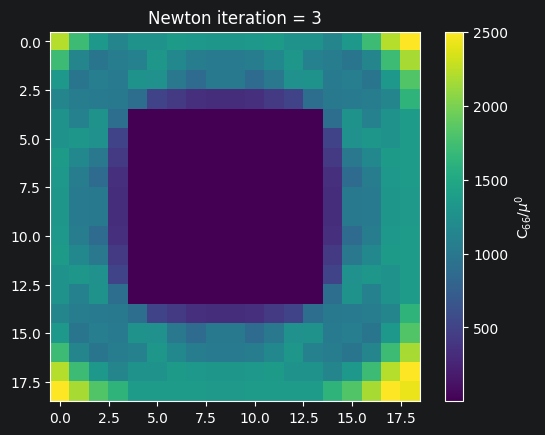

nb steps of CG = 277
  1.36e-01


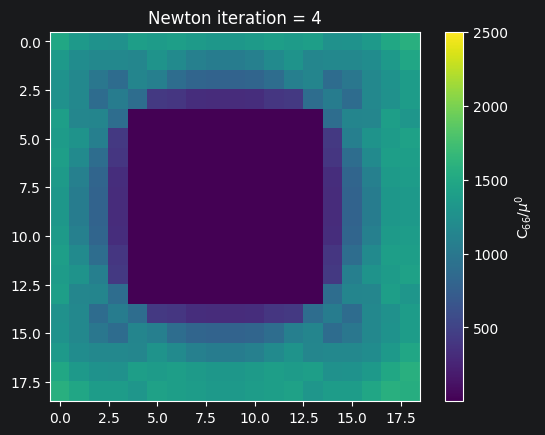

nb steps of CG = 285
  2.51e-02


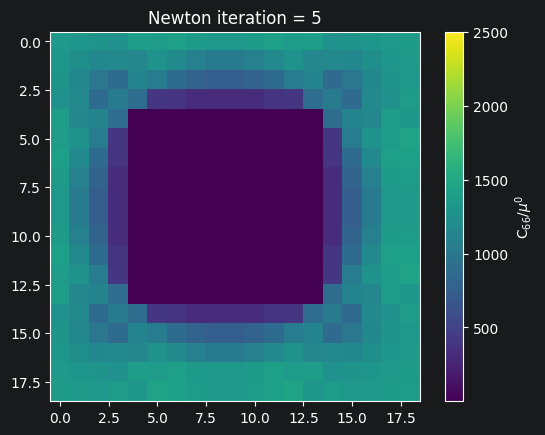

nb steps of CG = 313
  4.06e-03


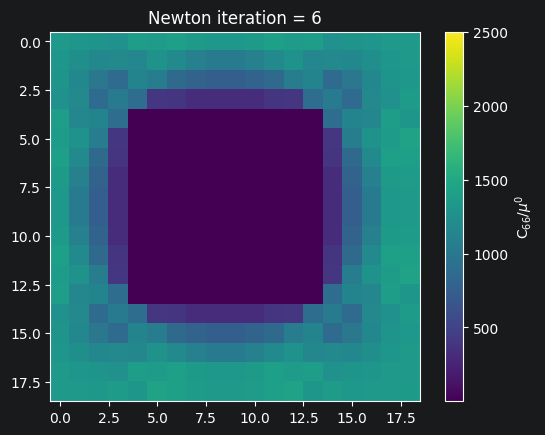

nb steps of CG = 312
  1.37e-04


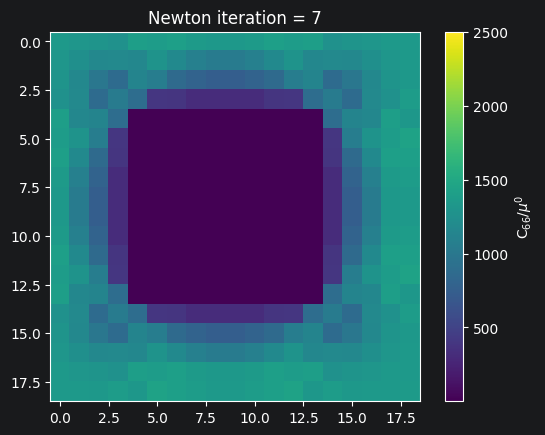

nb steps of CG = 308
  1.92e-07


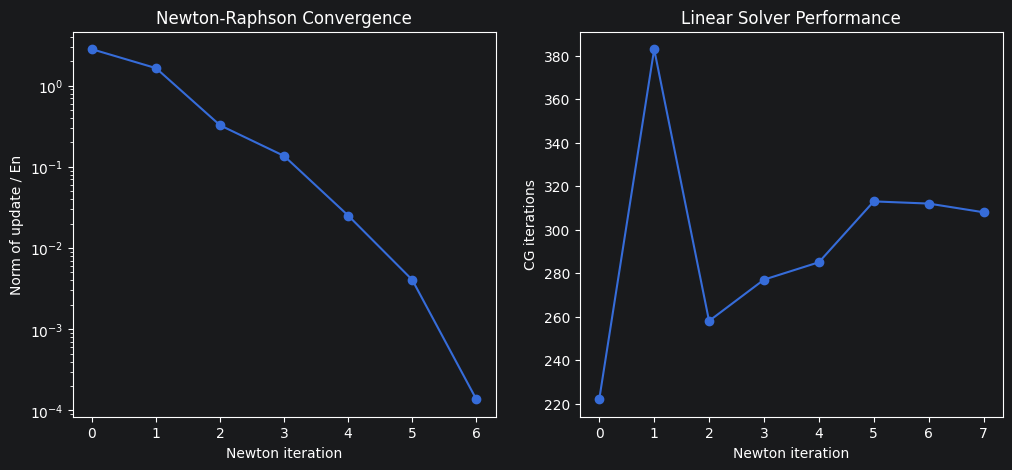

In [2]:
# Adapted from GooseFFT by T.W.J. de Geus and J. Vondřejc
# Original source: https://github.com/tdegeus/GooseFFT
# Original license: MIT License, Copyright (c) 2016 T.W.J. de Geus
#
# If using this in academic work, please also cite:
#   de Geus et al., Comput. Methods Appl. Mech. Eng., 2017, 318:412–430
#   https://doi.org/10.1016/j.cma.2016.12.032
#
# Modifications by Martin Ladecký, 2026:
# - The goal of this modification is to show that:
#     (1) Green operator preconditioned CG convergence slows down for problems
#         with high material contrast and smooth variation of data, and
#     (2) this observation is not specific to FEM discretization, but is present
#         also for the Fourier discretization.
# - Changed material parameters and microstructure geometry.
# - Added convergence monitoring and visualization of tangent stiffness field.
#
# MIT License
# Copyright (c) 2026 Martin Ladecký
#
# Permission is hereby granted, free of charge, to any person obtaining a copy
# of this software and associated documentation files (the "Software"), to deal
# in the Software without restriction, including without limitation the rights
# to use, copy, modify, merge, publish, distribute, sublicense, and/or sell
# copies of the Software, and to permit persons to whom the Software is
# furnished to do so, subject to the following conditions:
#
# The above copyright notice and this permission notice shall be included in all
# copies or substantial portions of the Software.
#
# THE SOFTWARE IS PROVIDED "AS IS", WITHOUT WARRANTY OF ANY KIND, EXPRESS OR
# IMPLIED, INCLUDING BUT NOT LIMITED TO THE WARRANTIES OF MERCHANTABILITY,
# FITNESS FOR A PARTICULAR PURPOSE AND NONINFRINGEMENT. IN NO EVENT SHALL THE
# AUTHORS OR COPYRIGHT HOLDERS BE LIABLE FOR ANY CLAIM, DAMAGES OR OTHER
# LIABILITY, WHETHER IN AN ACTION OF CONTRACT, TORT OR OTHERWISE, ARISING FROM,
# OUT OF OR IN CONNECTION WITH THE SOFTWARE OR THE USE OR OTHER DEALINGS IN THE
# SOFTWARE.

import numpy as np
import scipy.sparse.linalg as sp
import itertools
import matplotlib  as mpl

import matplotlib.pyplot as plt

# turn of warning for zero division (occurs due to vectorization)
np.seterr(divide='ignore', invalid='ignore')

# ----------------------------------- GRID ------------------------------------

Nx = 19  # number of voxels in x-direction
Ny = Nx  # number of voxels in y-direction
Nz = Nx  # number of voxels in z-direction
shape = [Nx, Ny, Nz]  # number of voxels as list: [Nx,Ny,Nz]
ndof = 3 ** 2 * Nx * Ny * Nz  # number of degrees-of-freedom

# ---------------------- PROJECTION, TENSORS, OPERATIONS ----------------------

# tensor operations/products: np.einsum enables index notation, avoiding loops
# e.g. ddot42 performs $C_ij = A_ijkl B_lk$ for the entire grid
trans2 = lambda A2: np.einsum('ijxyz          ->jixyz  ', A2)
ddot22 = lambda A2, B2: np.einsum('ijxyz  ,jixyz  ->xyz    ', A2, B2)
ddot42 = lambda A4, B2: np.einsum('ijklxyz,lkxyz  ->ijxyz  ', A4, B2)
ddot44 = lambda A4, B4: np.einsum('ijklxyz,lkmnxyz->ijmnxyz', A4, B4)
dot11 = lambda A1, B1: np.einsum('ixyz   ,ixyz   ->xyz    ', A1, B1)
dot22 = lambda A2, B2: np.einsum('ijxyz  ,jkxyz  ->ikxyz  ', A2, B2)
dot24 = lambda A2, B4: np.einsum('ijxyz  ,jkmnxyz->ikmnxyz', A2, B4)
dot42 = lambda A4, B2: np.einsum('ijklxyz,lmxyz  ->ijkmxyz', A4, B2)
dyad22 = lambda A2, B2: np.einsum('ijxyz  ,klxyz  ->ijklxyz', A2, B2)

# identity tensor                                               [single tensor]
i = np.eye(3)
# identity tensors                                            [grid of tensors]
I = np.einsum('ij,xyz', i, np.ones([Nx, Ny, Nz]))
I4 = np.einsum('ijkl,xyz->ijklxyz', np.einsum('il,jk', i, i), np.ones([Nx, Ny, Nz]))
I4rt = np.einsum('ijkl,xyz->ijklxyz', np.einsum('ik,jl', i, i), np.ones([Nx, Ny, Nz]))
II = dyad22(I, I)
I4s = (I4 + I4rt) / 2.
I4d = (I4s - II / 3.)

# projection operator (zero for zero frequency, associated with the mean)
# NB: vectorized version of "../linear-elasticity.py"
# - allocate / define support function
Ghat4 = np.zeros([3, 3, 3, 3, Nx, Ny, Nz])  # projection operator
x = np.zeros([3, Nx, Ny, Nz], dtype='int64')  # position vectors
q = np.zeros([3, Nx, Ny, Nz], dtype='int64')  # frequency vectors
delta = lambda i, j: i == j  # Dirac delta function
# - set "x" as position vector of all grid-points   [grid of vector-components]
x[0], x[1], x[2] = np.mgrid[:Nx, :Ny, :Nz]
# - convert positions "x" to frequencies "q"        [grid of vector-components]
for i in range(3):
    freq = np.arange(-(shape[i] - 1) / 2, +(shape[i] + 1) / 2, dtype='int64')
    q[i] = freq[x[i]]
# - compute "Q = ||q||", and "norm = 1/Q" being zero for the mean (Q==0)
#   NB: avoid zero division
q = q.astype(np.float64)
Q = dot11(q, q)
Z = Q == 0
Q[Z] = 1.
norm = 1. / Q
norm[Z] = 0.
# - set projection operator                                   [grid of tensors]
for i, j, l, m in itertools.product(range(3), repeat=4):
    Ghat4[i, j, l, m] = -(norm ** 2.) * (q[i] * q[j] * q[l] * q[m]) + \
                        .5 * norm * (delta(j, l) * q[i] * q[m] + delta(j, m) * q[i] * q[l] + \
                                     delta(i, l) * q[j] * q[m] + delta(i, m) * q[j] * q[l])

# (inverse) Fourier transform (for each tensor component in each direction)
fft = lambda x: np.fft.fftshift(np.fft.fftn(np.fft.ifftshift(x), [Nx, Ny, Nz]))
ifft = lambda x: np.fft.fftshift(np.fft.ifftn(np.fft.ifftshift(x), [Nx, Ny, Nz]))

# functions for the projection 'G', and the product 'G : K : eps'
G = lambda A2: np.real(ifft(ddot42(Ghat4, fft(A2)))).reshape(-1)
K_deps = lambda depsm: ddot42(K4, depsm.reshape(3, 3, Nx, Ny, Nz))
G_K_deps = lambda depsm: G(K_deps(depsm))


# ------------------- PROBLEM DEFINITION / CONSTITIVE MODEL -------------------

# linear elasticity
# -----------------

mu = 0.1  # shear modulus
def elastic(eps):
    # parameters
    K = 2* mu# bulk  modulus

    # elastic stiffness tensor, and stress response
    C4 = K * II + 2. * mu * I4d
    sig = ddot42(C4, eps)

    return sig, C4


# non-linear elasticity
# ---------------------

def nonlin_elastic(eps):
    K = 20*mu  # bulk modulus
    sig0 = 5*mu  # reference stress
    eps0 = 0.01  # reference strain
    n = 3.  # hardening exponent

    epsm = ddot22(eps, I) / 3. # trace
    epsd = eps - epsm * I
    epseq = np.sqrt(2. / 3. * ddot22(epsd, epsd))
    sig = 3. * K * epsm * I + 2. / 3. * sig0 / (eps0 ** n) * (epseq ** (n - 1.)) * epsd
    sig = 3. * K * epsm * I * (epseq == 0.).astype(float) + sig * (epseq != 0.).astype(float)

    K4_d = 2. / 3. * sig0 / (eps0 ** n) * (
                dyad22(epsd, epsd) * 2. / 3. * (n - 1.) * epseq ** (n - 3.) + epseq ** (n - 1.) * I4d)
    K4 = K * II + K4_d * (epseq != 0.).astype(float)

    return sig, K4


# Cuboid inclusion

def constitutive(eps):
    phase = np.ones([Nx,Ny,Nz])

    phase[Nx//4:3*Nx//4,Ny//4:3*Ny//4,Nz//4:3*Nz//4] = 0.

    sig_P1, K4_P1 = nonlin_elastic(eps)
    sig_P2, K4_P2 = elastic(eps)

    sig = phase * sig_P1 + (1. - phase) * sig_P2
    K4 = phase * K4_P1 + (1. - phase) * K4_P2

    return sig, K4


# ----------------------------- NEWTON ITERATIONS -----------------------------

# initialize: strain and stress/tangent
eps = np.zeros([3, 3, Nx, Ny, Nz])
sig, K4 = constitutive(eps)

# set macroscopic loading
DE = np.zeros([3, 3, Nx, Ny, Nz])
DE[0, 1] += 0.025
DE[1, 0] += 0.025

# initial residual: distribute "DE" over grid using "K4"
sig, K4 = constitutive(DE)
b = -G_K_deps(DE)
eps += DE

# compute DOF-normalization, set Newton iteration counter
En = np.linalg.norm(eps)
iiter = 0

# iterate as long as the iterative update does not vanish
norm_fluctuation=[]
nb_iter_CG_per_Newthon=[]
while True:
    # plot data
    # normalization
    norm = mpl.colors.Normalize(vmin=1, vmax=2500)

    fig, ax = plt.subplots()
    ax.set_title('Newton iteration = {}'.format(iiter))
    im = ax.imshow(K4[0, 1, 0, 1, :, :, Nz // 2] / mu, cmap='viridis', norm=norm)
    cbar = fig.colorbar(im, ax=ax)
    cbar.set_label(r'$\mathrm{C}_{66}/\mu^0$')
    plt.show()
    #
    nb_iter_CG = 0

    def callback(x):
        global nb_iter_CG
        nb_iter_CG += 1


    # solve linear system using the Conjugate Gradient iterative solver
    depsm, _ = sp.cg(rtol=1.e-5,
                     A=sp.LinearOperator(shape=(ndof, ndof), matvec=G_K_deps),
                     b=b,
                     callback=callback
                     )
    print(f'nb steps of CG = {nb_iter_CG}')
    nb_iter_CG_per_Newthon.append(nb_iter_CG)
    # add solution of linear system to DOFs
    eps += depsm.reshape(3, 3, Nx, Ny, Nz)

    # new residual
    sig, K4 = constitutive(eps)

    b = -G(sig)
    # check for convergence
    print('{0:10.2e}'.format(np.linalg.norm(depsm) / En))
    if np.linalg.norm(depsm) / En < 1.e-4 and iiter > 0: break

    # update Newton iteration counter
    iiter += 1
    norm_fluctuation.append(np.linalg.norm(depsm))

import matplotlib.pyplot as plt

# Plot results
plt.figure(figsize=(12, 5))
plt.subplot(1, 2, 1)
plt.semilogy(norm_fluctuation/ En, 'o-')
plt.xlabel('Newton iteration')
plt.ylabel('Norm of update / En')
plt.title('Newton-Raphson Convergence')

plt.subplot(1, 2, 2)
plt.plot(nb_iter_CG_per_Newthon, 'o-')
plt.xlabel('Newton iteration')
plt.ylabel('CG iterations')
plt.title('Linear Solver Performance')
plt.show()